In [46]:
import os
import io
import zipfile
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


In [47]:
BASE = fetch_dataset()

features = pd.read_csv(
    os.path.join(BASE, "features.txt"),
    sep=r"\s+",
    header=None,
    names=["index", "feature"],
)

raw_names = features["feature"].tolist()
seen = {}
feature_names = []
for name in raw_names:
    if name in seen:
        seen[name] += 1
        feature_names.append(f"{name}_{seen[name]}")
    else:
        seen[name] = 0
        feature_names.append(name)

activity_map = pd.read_csv(
    os.path.join(BASE, "activity_labels.txt"),
    sep=r"\s+",
    header=None,
    names=["id", "activity"],
)
activity_lookup = dict(zip(activity_map["id"], activity_map["activity"]))


def load_split(split):
    X = pd.read_csv(
        os.path.join(BASE, split, f"X_{split}.txt"),
        sep=r"\s+",
        header=None,
        names=feature_names,
    )
    y = pd.read_csv(
        os.path.join(BASE, split, f"y_{split}.txt"),
        sep=r"\s+",
        header=None,
        names=["activity_id"],
    )
    subject = pd.read_csv(
        os.path.join(BASE, split, f"subject_{split}.txt"),
        sep=r"\s+",
        header=None,
        names=["subject"],
    )
    X = X.reset_index(drop=True)
    X["activity_id"] = y["activity_id"].values
    X["subject"] = subject["subject"].values
    X["split"] = split
    return X


train_df = load_split("train")
test_df = load_split("test")
data = pd.concat([train_df, test_df], ignore_index=True)
data["activity"] = data["activity_id"].map(activity_lookup)

print("Total samples:", data.shape[0])
print("Total features:", len(feature_names))
data[feature_names[:6] + ["activity", "subject", "split"]].head()

Total samples: 10299
Total features: 561


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,activity,subject,split
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,STANDING,1,train
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,STANDING,1,train
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,STANDING,1,train
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,STANDING,1,train
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,STANDING,1,train


In [48]:
X_all = data[feature_names].copy()

print("Missing values in feature matrix:", int(X_all.isnull().sum().sum()))
print("Infinite values in feature matrix:", int(np.isinf(X_all.values).sum()))
print("Duplicate rows:", int(X_all.duplicated().sum()))
print("Constant (zero-variance) features:", int((X_all.std() == 0).sum()))
print()
print("Class distribution:")
print(data["activity"].value_counts())

Missing values in feature matrix: 0
Infinite values in feature matrix: 0
Duplicate rows: 0
Constant (zero-variance) features: 0

Class distribution:
activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [49]:
encoder = LabelEncoder()
data["activity_encoded"] = encoder.fit_transform(data["activity"])
label_names = list(encoder.classes_)

for code_value, name in enumerate(label_names):
    print(code_value, "->", name)

0 -> LAYING
1 -> SITTING
2 -> STANDING
3 -> WALKING
4 -> WALKING_DOWNSTAIRS
5 -> WALKING_UPSTAIRS


In [50]:
SAMPLE_SIZE = 4000

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(data):
    sample = (
        data.groupby("activity", group_keys=False)
        .apply(lambda g: g.sample(
            n=max(1, int(round(SAMPLE_SIZE * len(g) / len(data)))),
            random_state=RANDOM_STATE,
        ))
        .reset_index(drop=True)
    )
else:
    sample = data.copy()

sample = sample.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

X_raw = sample[feature_names].values
y_true = sample["activity_encoded"].values
y_names = sample["activity"].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Working matrix shape:", X.shape)
print("Mean after scaling (approx):", round(float(X.mean()), 6))
print("Std after scaling (approx):", round(float(X.std()), 6))
print()
print(sample["activity"].value_counts())

Working matrix shape: (4000, 561)
Mean after scaling (approx): 0.0
Std after scaling (approx): 1.0

activity
LAYING                755
STANDING              740
SITTING               690
WALKING               669
WALKING_UPSTAIRS      600
WALKING_DOWNSTAIRS    546
Name: count, dtype: int64


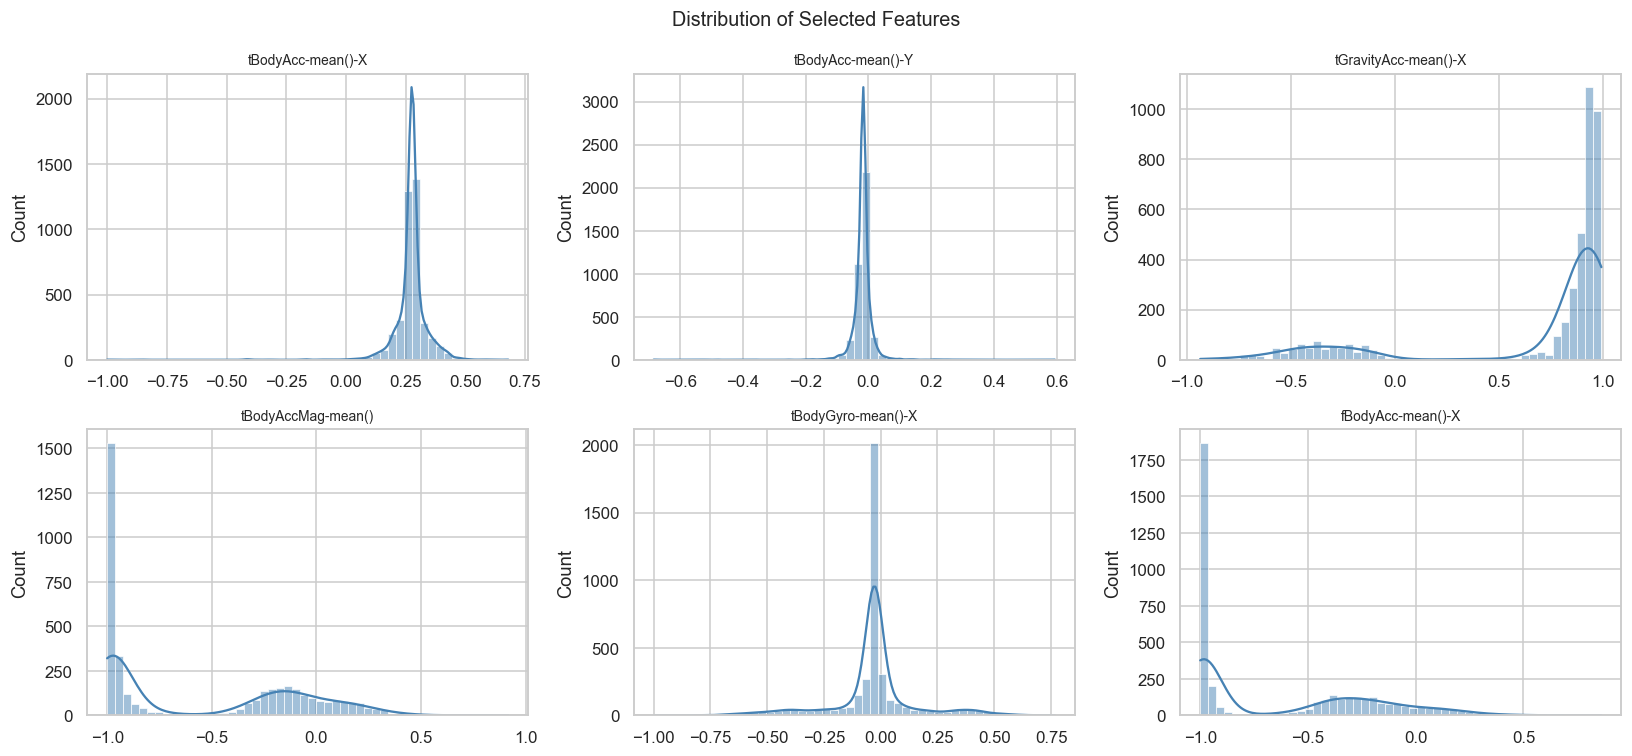

In [51]:
eda_features = [
    "tBodyAcc-mean()-X",
    "tBodyAcc-mean()-Y",
    "tGravityAcc-mean()-X",
    "tBodyAccMag-mean()",
    "tBodyGyro-mean()-X",
    "fBodyAcc-mean()-X",
]
eda_features = [f for f in eda_features if f in sample.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feature in zip(axes.ravel(), eda_features):
    sns.histplot(sample[feature], bins=50, kde=True, ax=ax, color="steelblue")
    ax.set_title(feature, fontsize=9)
    ax.set_xlabel("")
fig.suptitle("Distribution of Selected Features", fontsize=13)
fig.tight_layout()
plt.show()

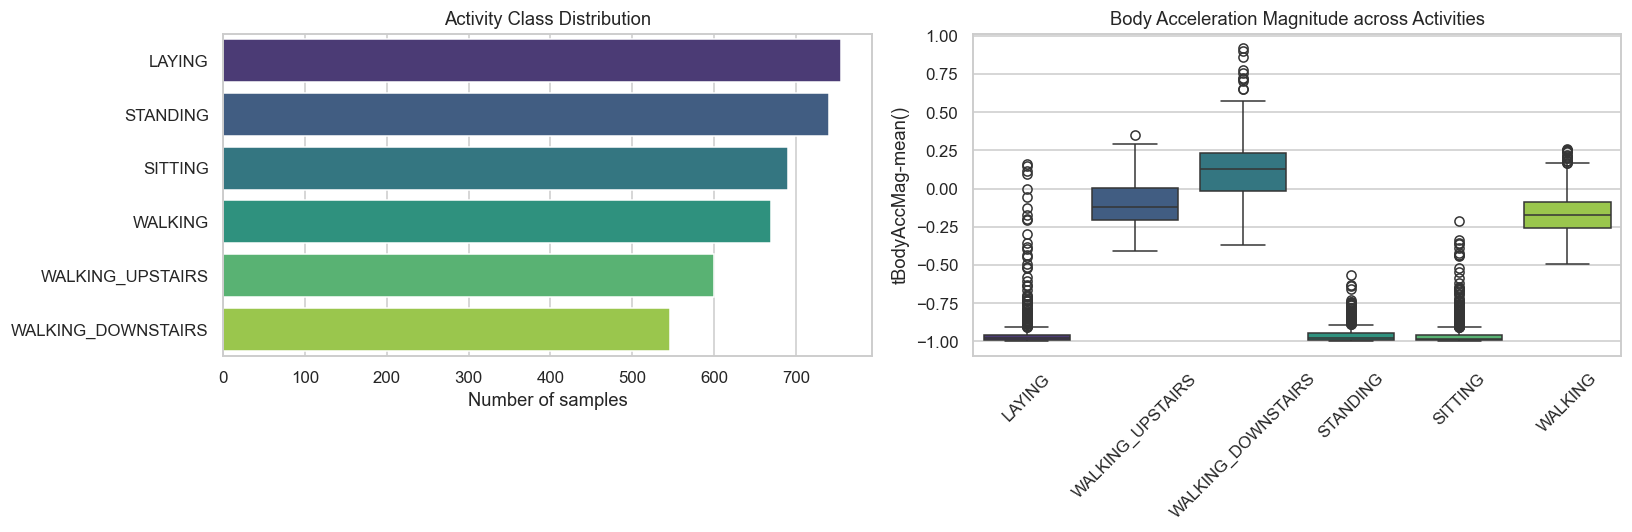

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(
    y=sample["activity"],
    order=sample["activity"].value_counts().index,
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Activity Class Distribution")
axes[0].set_xlabel("Number of samples")
axes[0].set_ylabel("")

sns.boxplot(
    data=sample,
    x="activity",
    y="tBodyAccMag-mean()" if "tBodyAccMag-mean()" in sample.columns else eda_features[0],
    ax=axes[1],
    palette="viridis",
)
axes[1].set_title("Body Acceleration Magnitude across Activities")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

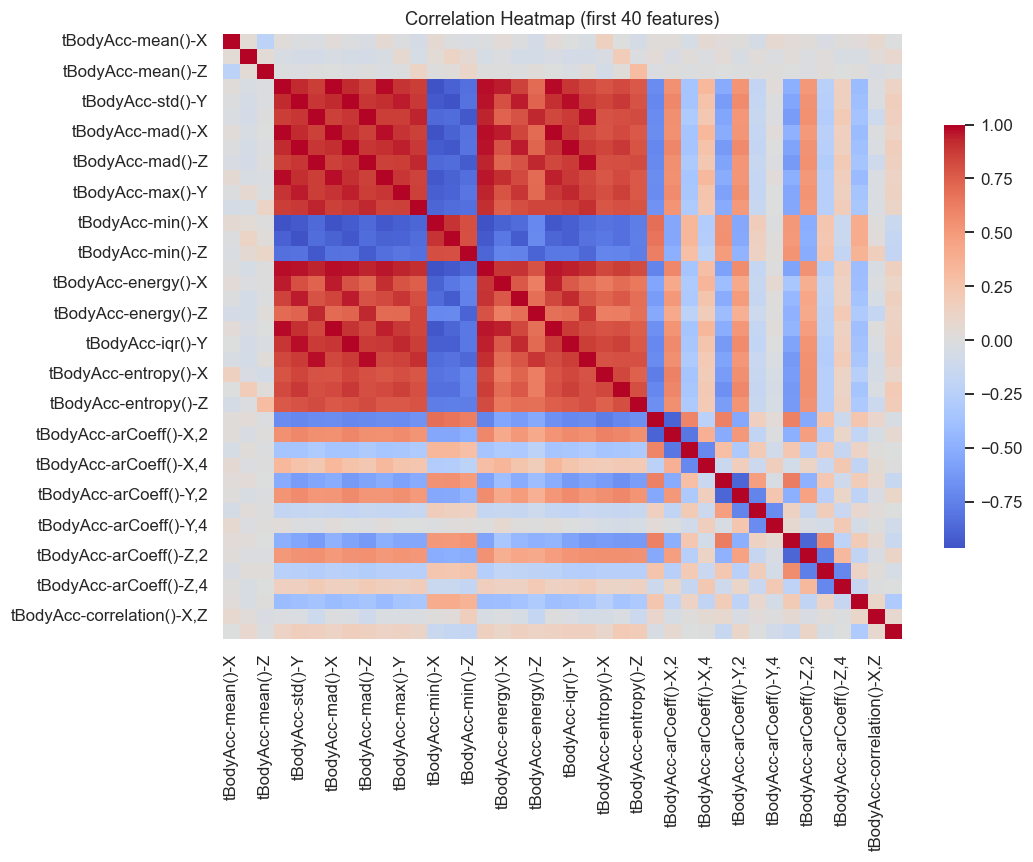

In [53]:
corr_subset = sample[feature_names[:40]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.7})
plt.title("Correlation Heatmap (first 40 features)")
plt.tight_layout()
plt.show()

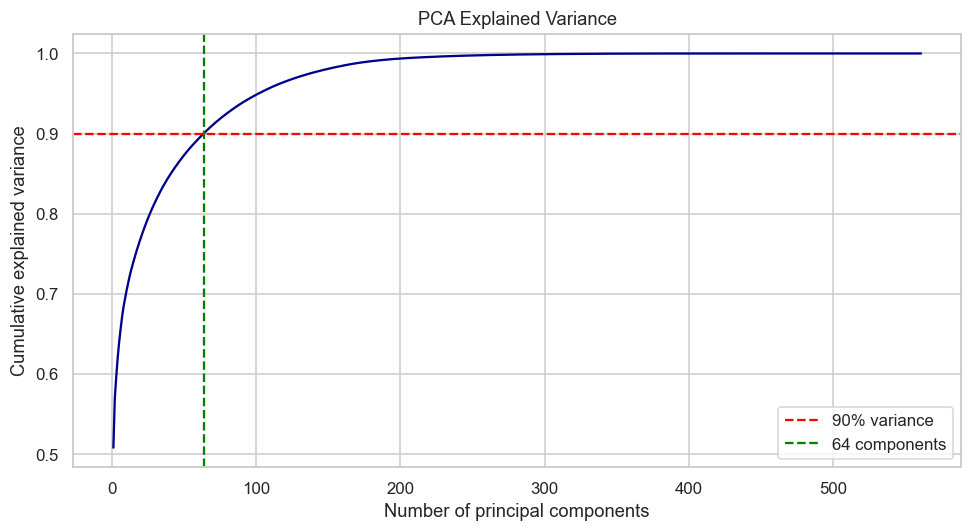

Components needed for 90% variance: 64
Variance explained by first 2 components: 57.0 %


In [54]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X)
explained = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = int(np.searchsorted(explained, 0.90) + 1)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(explained) + 1), explained, color="darkblue")
plt.axhline(0.90, color="red", linestyle="--", label="90% variance")
plt.axvline(n_comp_90, color="green", linestyle="--", label=f"{n_comp_90} components")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print("Components needed for 90% variance:", n_comp_90)
print("Variance explained by first 2 components:", round(float(explained[1]) * 100, 2), "%")

In [55]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X)

pca_reduced = PCA(n_components=n_comp_90, random_state=RANDOM_STATE)
X_pca_reduced = pca_reduced.fit_transform(X)

pca50 = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca50 = pca50.fit_transform(X)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X_pca50)

print("PCA (2D) shape:", X_pca2.shape)
print("PCA (90% variance) shape:", X_pca_reduced.shape)
print("t-SNE (2D) shape:", X_tsne.shape)

PCA (2D) shape: (4000, 2)
PCA (90% variance) shape: (4000, 64)
t-SNE (2D) shape: (4000, 2)


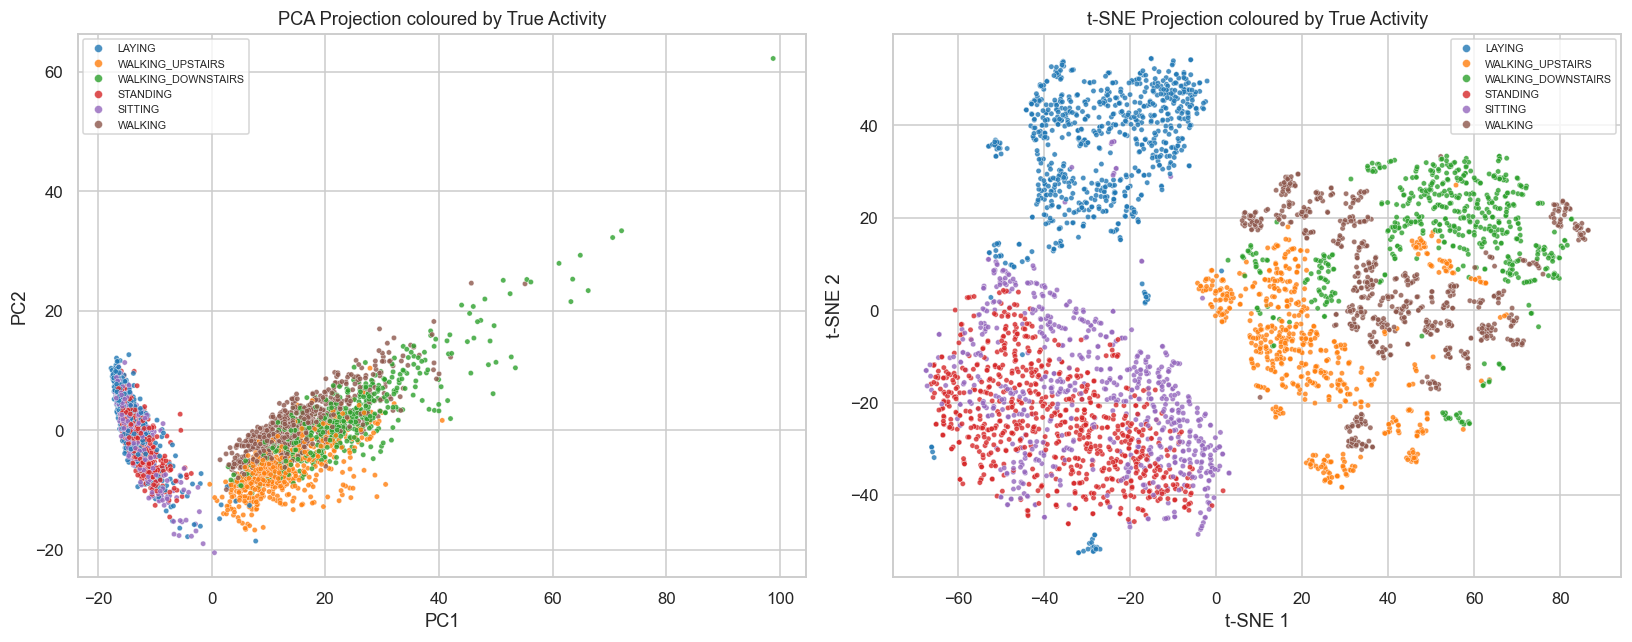

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    x=X_pca2[:, 0], y=X_pca2[:, 1], hue=y_names,
    palette="tab10", s=12, alpha=0.8, ax=axes[0],
)
axes[0].set_title("PCA Projection coloured by True Activity")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=7, markerscale=1.5)

sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_names,
    palette="tab10", s=12, alpha=0.8, ax=axes[1],
)
axes[1].set_title("t-SNE Projection coloured by True Activity")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(fontsize=7, markerscale=1.5)

fig.tight_layout()
plt.show()

In [57]:
def evaluate_clustering(name, X_data, labels, y_reference):
    labels = np.asarray(labels)
    mask = labels != -1
    unique_clusters = set(labels[mask])
    n_clusters = len(unique_clusters)
    noise_ratio = float((~mask).sum()) / len(labels)

    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X_data[mask], labels[mask])
        dbi = davies_bouldin_score(X_data[mask], labels[mask])
        chi = calinski_harabasz_score(X_data[mask], labels[mask])
    else:
        sil, dbi, chi = np.nan, np.nan, np.nan

    return {
        "Algorithm": name,
        "Clusters": n_clusters,
        "Noise %": round(noise_ratio * 100, 2),
        "Silhouette": round(float(sil), 4) if sil == sil else np.nan,
        "Davies-Bouldin": round(float(dbi), 4) if dbi == dbi else np.nan,
        "Calinski-Harabasz": round(float(chi), 2) if chi == chi else np.nan,
        "ARI": round(float(adjusted_rand_score(y_reference, labels)), 4),
        "NMI": round(float(normalized_mutual_info_score(y_reference, labels)), 4),
    }


def map_clusters_to_labels(labels, y_reference, class_names):
    labels = np.asarray(labels)
    valid = labels != -1
    cluster_ids = sorted(set(labels[valid]))
    cost = np.zeros((len(cluster_ids), len(class_names)))
    for i, cid in enumerate(cluster_ids):
        for j in range(len(class_names)):
            cost[i, j] = -np.sum((labels == cid) & (y_reference == j))
    rows, cols = linear_sum_assignment(cost)
    mapping = {cluster_ids[r]: cols[c] for c, r in enumerate(rows)}
    mapped = np.array([mapping.get(l, -1) for l in labels])
    return mapped, mapping


def plot_clusters(embedding_pca, embedding_tsne, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    palette = sns.color_palette("tab10", len(set(labels)))

    sns.scatterplot(
        x=embedding_pca[:, 0], y=embedding_pca[:, 1],
        hue=labels, palette=palette, s=12, alpha=0.8, ax=axes[0], legend="full",
    )
    axes[0].set_title(f"{title} — PCA")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend(fontsize=7, title="Cluster")

    sns.scatterplot(
        x=embedding_tsne[:, 0], y=embedding_tsne[:, 1],
        hue=labels, palette=palette, s=12, alpha=0.8, ax=axes[1], legend="full",
    )
    axes[1].set_title(f"{title} — t-SNE")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")
    axes[1].legend(fontsize=7, title="Cluster")

    fig.tight_layout()
    plt.show()


def plot_cluster_activity_matrix(labels, y_reference, class_names, title):
    valid = np.asarray(labels) != -1
    table = pd.crosstab(
        pd.Series(np.asarray(labels)[valid], name="Cluster"),
        pd.Series(np.asarray(class_names)[valid], name="True Activity"),
    )
    plt.figure(figsize=(9, 4.5))
    sns.heatmap(table, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return table

In [58]:
k_values = list(range(2, 9))
wcss = []
sil_scores = []
dbi_scores = []
chi_scores = []
ari_scores = []
nmi_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels_k))
    dbi_scores.append(davies_bouldin_score(X, labels_k))
    chi_scores.append(calinski_harabasz_score(X, labels_k))
    ari_scores.append(adjusted_rand_score(y_true, labels_k))
    nmi_scores.append(normalized_mutual_info_score(y_true, labels_k))
    print(f"k = {k} completed")

elbow_table = pd.DataFrame({
    "Number of Clusters (k)": k_values,
    "WCSS (Inertia)": np.round(wcss, 2),
    "Silhouette Score": np.round(sil_scores, 4),
    "Davies-Bouldin": np.round(dbi_scores, 4),
    "Calinski-Harabasz": np.round(chi_scores, 2),
    "ARI": np.round(ari_scores, 4),
    "NMI": np.round(nmi_scores, 4),
})

k = 2 completed
k = 3 completed
k = 4 completed
k = 5 completed
k = 6 completed
k = 7 completed
k = 8 completed


In [59]:
print("Table 1: K-Means Elbow Method Results")
print()
print(elbow_table.to_string(index=False))
elbow_table

Table 1: K-Means Elbow Method Results

 Number of Clusters (k)  WCSS (Inertia)  Silhouette Score  Davies-Bouldin  Calinski-Harabasz    ARI    NMI
                      2      1273105.20            0.3928          1.0720            3048.95 0.3295 0.5456
                      3      1135729.20            0.3124          1.7838            1950.18 0.3325 0.5199
                      4      1082765.75            0.1450          2.3606            1428.53 0.2975 0.4668
                      5      1031244.85            0.1260          2.4021            1174.54 0.2906 0.4602
                      6      1001922.85            0.1130          2.3635             990.27 0.4227 0.5619
                      7       980789.33            0.1016          2.3430             857.13 0.4177 0.5609
                      8       958516.62            0.0791          2.6801             764.82 0.4400 0.5530


,Number of Clusters (k),WCSS (Inertia),Silhouette Score,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,2,1273105.20,0.3928,1.0720,3048.95,0.3295,0.5456
1,3,1135729.20,0.3124,1.7838,1950.18,0.3325,0.5199
2,4,1082765.75,0.1450,2.3606,1428.53,0.2975,0.4668
3,5,1031244.85,0.1260,2.4021,1174.54,0.2906,0.4602
4,6,1001922.85,0.1130,2.3635,990.27,0.4227,0.5619
5,7,980789.33,0.1016,2.3430,857.13,0.4177,0.5609
6,8,958516.62,0.0791,2.6801,764.82,0.4400,0.5530


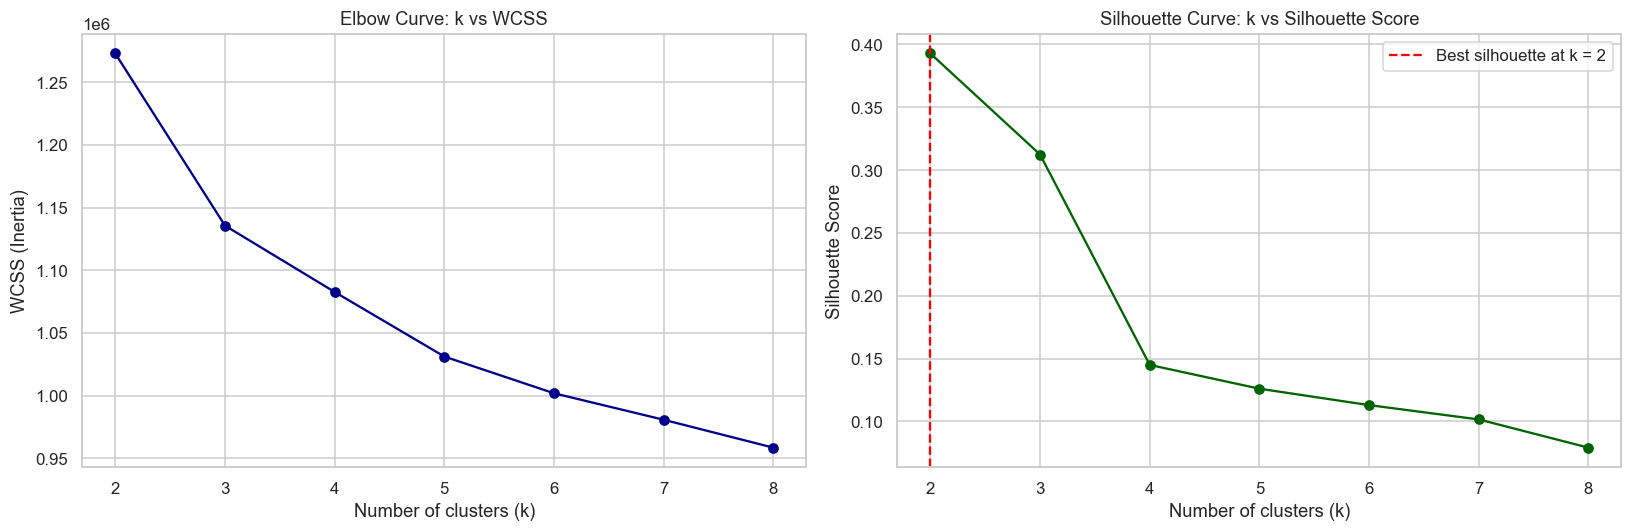

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(k_values, wcss, marker="o", color="darkblue")
axes[0].set_title("Elbow Curve: k vs WCSS")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")

axes[1].plot(k_values, sil_scores, marker="o", color="darkgreen")
axes[1].set_title("Silhouette Curve: k vs Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

best_by_sil = k_values[int(np.argmax(sil_scores))]
axes[1].axvline(best_by_sil, color="red", linestyle="--", label=f"Best silhouette at k = {best_by_sil}")
axes[1].legend()

fig.tight_layout()
plt.show()

In [61]:
deltas = np.diff(wcss)
second_diff = np.diff(deltas)
elbow_k = k_values[int(np.argmax(second_diff)) + 1]

print("Drop in WCSS between consecutive k values:")
for i, k in enumerate(k_values[1:]):
    print(f"  k = {k_values[i]} -> {k}: reduction = {abs(deltas[i]):.2f}")
print()
print("Elbow point suggested by the curvature of the WCSS curve: k =", elbow_k)
print("k with the highest Silhouette Score:", best_by_sil)
print("Number of ground-truth activities in the dataset: 6")

Drop in WCSS between consecutive k values:
  k = 2 -> 3: reduction = 137376.00
  k = 3 -> 4: reduction = 52963.45
  k = 4 -> 5: reduction = 51520.90
  k = 5 -> 6: reduction = 29322.00
  k = 6 -> 7: reduction = 21133.52
  k = 7 -> 8: reduction = 22272.71

Elbow point suggested by the curvature of the WCSS curve: k = 3
k with the highest Silhouette Score: 2
Number of ground-truth activities in the dataset: 6


In [62]:
BEST_K = best_by_sil
FINAL_K = 6

kmeans_best = KMeans(n_clusters=BEST_K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
labels_km_best = kmeans_best.fit_predict(X)

kmeans_final = KMeans(n_clusters=FINAL_K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
labels_km = kmeans_final.fit_predict(X)

result_km_best = evaluate_clustering(f"K-Means (k={BEST_K})", X, labels_km_best, y_true)
result_km = evaluate_clustering(f"K-Means (k={FINAL_K})", X, labels_km, y_true)

pd.DataFrame([result_km_best, result_km])

,Algorithm,Clusters,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means (k=2),2,0.0,0.3928,1.0720,3048.95,0.3295,0.5456
1,K-Means (k=6),6,0.0,0.1130,2.3635,990.27,0.4227,0.5619


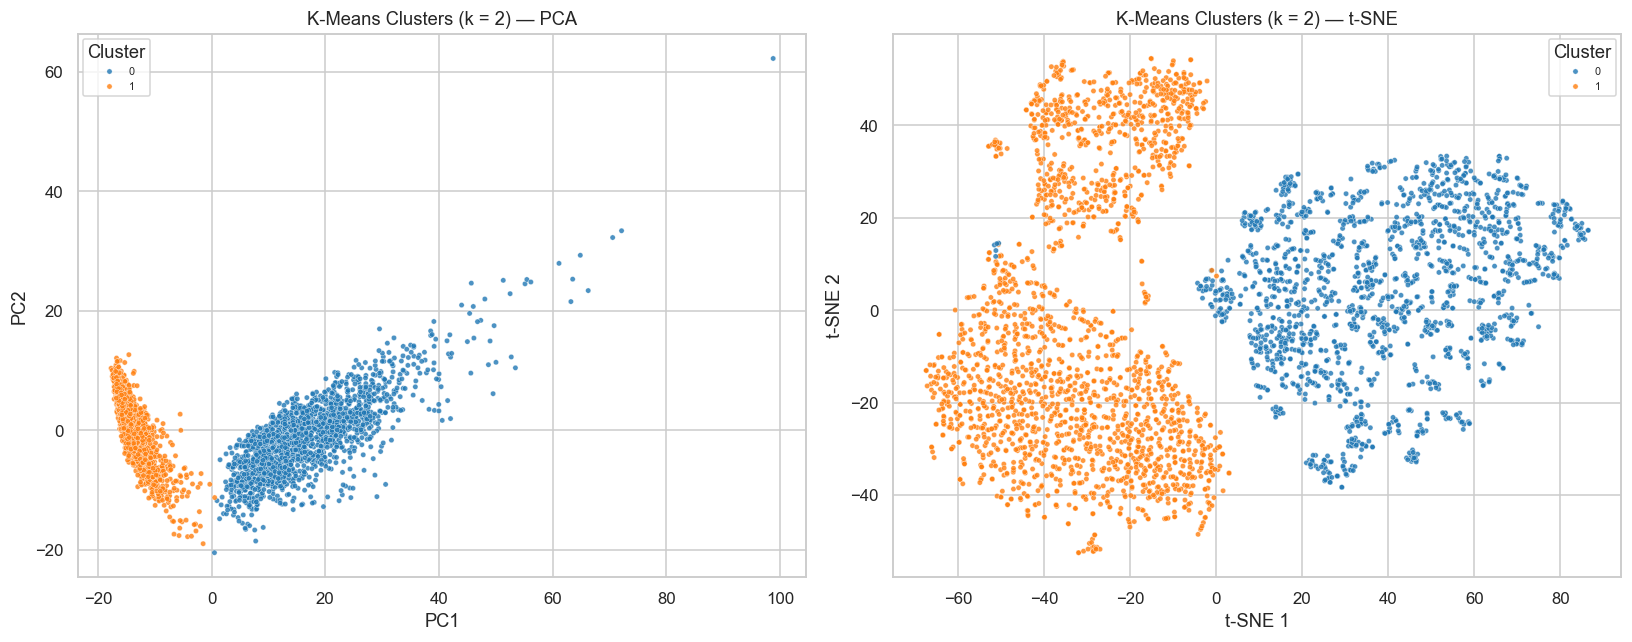

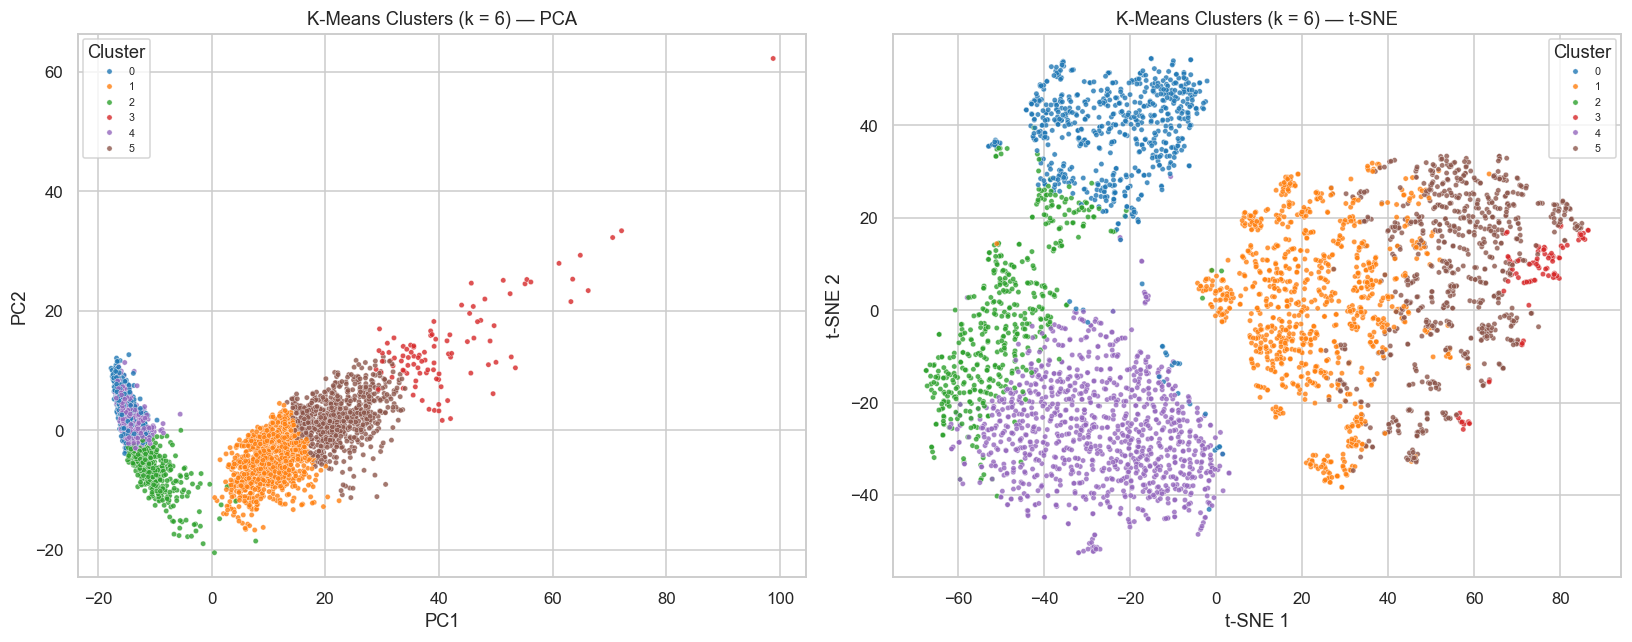

In [63]:
plot_clusters(X_pca2, X_tsne, labels_km_best, f"K-Means Clusters (k = {BEST_K})")
plot_clusters(X_pca2, X_tsne, labels_km, f"K-Means Clusters (k = {FINAL_K})")

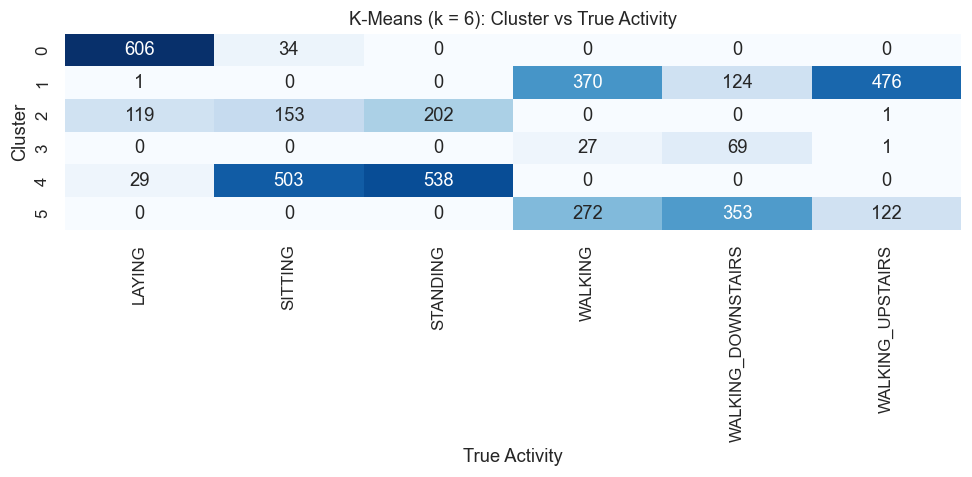

True Activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
Cluster,,,,,,
0,606,34,0,0,0,0
1,1,0,0,370,124,476
2,119,153,202,0,0,1
3,0,0,0,27,69,1
4,29,503,538,0,0,0
5,0,0,0,272,353,122


In [64]:
km_table = plot_cluster_activity_matrix(
    labels_km, y_true, y_names, f"K-Means (k = {FINAL_K}): Cluster vs True Activity"
)
km_table

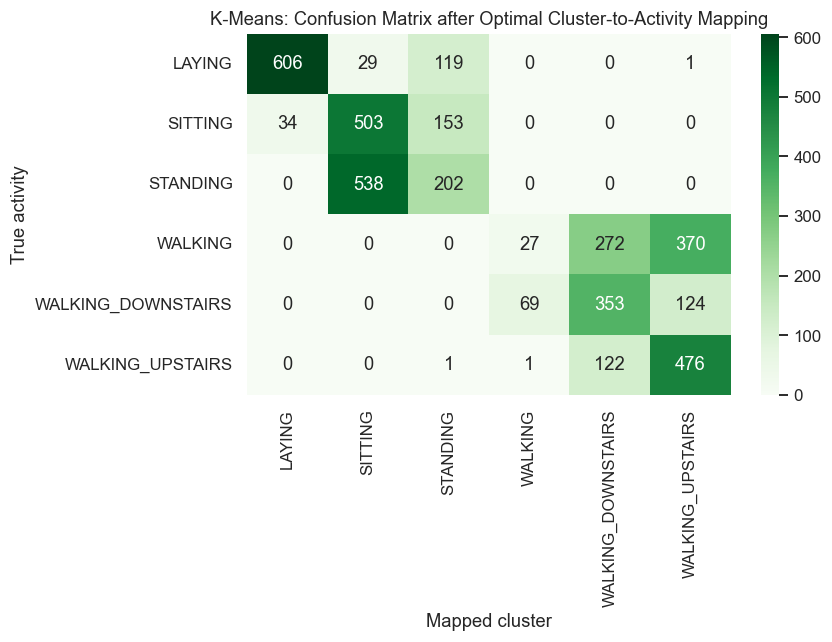

Cluster-to-activity matching accuracy: 54.17 %


In [65]:
mapped_km, mapping_km = map_clusters_to_labels(labels_km, y_true, label_names)
cm_km = confusion_matrix(y_true, mapped_km, labels=range(len(label_names)))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_km, annot=True, fmt="d", cmap="Greens",
    xticklabels=label_names, yticklabels=label_names,
)
plt.title("K-Means: Confusion Matrix after Optimal Cluster-to-Activity Mapping")
plt.xlabel("Mapped cluster")
plt.ylabel("True activity")
plt.tight_layout()
plt.show()

accuracy_km = float((mapped_km == y_true).mean())
print("Cluster-to-activity matching accuracy:", round(accuracy_km * 100, 2), "%")

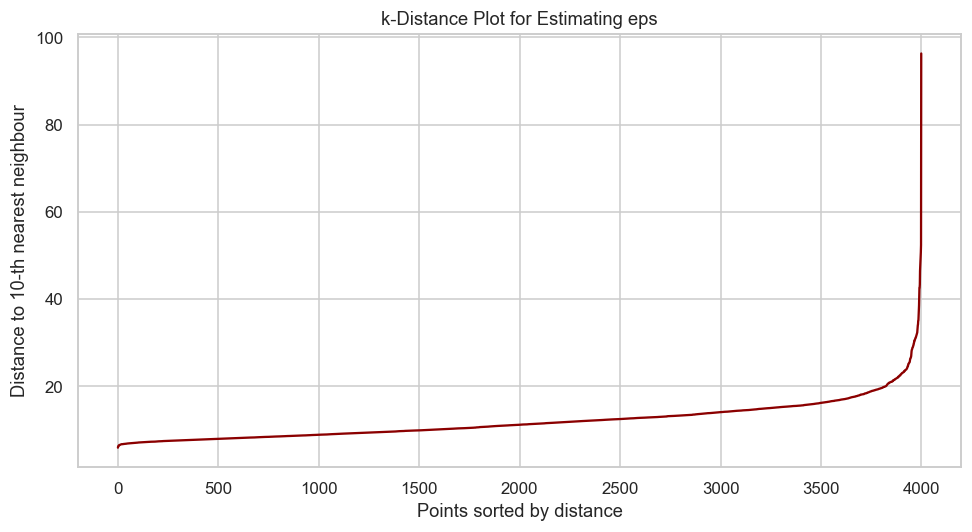

90th percentile of k-distances (initial eps estimate): 16.928


In [66]:
X_db = X_pca_reduced
MIN_PTS_REF = 10

neighbors = NearestNeighbors(n_neighbors=MIN_PTS_REF).fit(X_db)
distances, _ = neighbors.kneighbors(X_db)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color="darkred")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {MIN_PTS_REF}-th nearest neighbour")
plt.title("k-Distance Plot for Estimating eps")
plt.tight_layout()
plt.show()

knee_estimate = float(np.percentile(k_distances, 90))
print("90th percentile of k-distances (initial eps estimate):", round(knee_estimate, 3))

In [67]:
eps_grid = np.round(np.linspace(knee_estimate * 0.5, knee_estimate * 1.6, 12), 3)
min_pts_grid = [5, 10, 20, 30]

records = []
for min_pts in min_pts_grid:
    for eps in eps_grid:
        labels_try = DBSCAN(eps=eps, min_samples=min_pts, n_jobs=-1).fit_predict(X_db)
        mask = labels_try != -1
        n_clusters = len(set(labels_try[mask]))
        noise = float((~mask).sum()) / len(labels_try)
        if n_clusters >= 2 and mask.sum() > n_clusters:
            sil = silhouette_score(X_db[mask], labels_try[mask])
        else:
            sil = np.nan
        records.append({
            "eps": eps,
            "minPts": min_pts,
            "Clusters": n_clusters,
            "Noise %": round(noise * 100, 2),
            "Silhouette": round(float(sil), 4) if sil == sil else np.nan,
            "ARI": round(float(adjusted_rand_score(y_true, labels_try)), 4),
            "NMI": round(float(normalized_mutual_info_score(y_true, labels_try)), 4),
        })

grid_results = pd.DataFrame(records)
grid_results.head(20)

,eps,minPts,Clusters,Noise %,Silhouette,ARI,NMI
0,8.464,5,11,63.70,0.0267,0.1144,0.2499
1,10.157,5,17,44.70,0.1171,0.2216,0.3913
2,11.849,5,15,26.07,0.3339,0.3012,0.4542
3,13.542,5,12,14.70,0.3299,0.3162,0.4755
4,15.235,5,2,7.55,0.3397,0.0144,0.0555
5,16.928,5,2,4.42,0.3590,0.0069,0.0336
6,18.620,5,1,2.73,NaN,0.0031,0.0183
7,20.313,5,1,1.65,NaN,0.0016,0.0119
8,22.006,5,1,1.18,NaN,0.0012,0.0108
9,23.699,5,1,1.05,NaN,0.0009,0.0087


In [68]:
viable = grid_results[
    (grid_results["Clusters"] >= 2)
    & (grid_results["Clusters"] <= 12)
    & (grid_results["Noise %"] < 40)
].dropna(subset=["Silhouette"])

print("Top 10 parameter combinations ranked by Silhouette Score:")
print(viable.sort_values("Silhouette", ascending=False).head(10).to_string(index=False))
print()
print("Top 10 parameter combinations ranked by ARI:")
print(viable.sort_values("ARI", ascending=False).head(10).to_string(index=False))

Top 10 parameter combinations ranked by Silhouette Score:
   eps  minPts  Clusters  Noise %  Silhouette    ARI    NMI
13.542      20         2    22.50      0.4568 0.3149 0.4695
13.542      30         2    24.70      0.4555 0.3095 0.4643
11.849      30         2    39.25      0.4537 0.2704 0.4225
13.542      10         3    19.35      0.3956 0.3172 0.4731
11.849      20         3    36.88      0.3861 0.2728 0.4253
11.849      10         4    31.90      0.3824 0.2885 0.4411
16.928       5         2     4.42      0.3590 0.0069 0.0336
15.235       5         2     7.55      0.3397 0.0144 0.0555
13.542       5        12    14.70      0.3299 0.3162 0.4755
15.235      10         3     9.22      0.2781 0.0180 0.0659

Top 10 parameter combinations ranked by ARI:
   eps  minPts  Clusters  Noise %  Silhouette    ARI    NMI
13.542      10         3    19.35      0.3956 0.3172 0.4731
13.542       5        12    14.70      0.3299 0.3162 0.4755
13.542      20         2    22.50      0.4568 0.3149 0.4

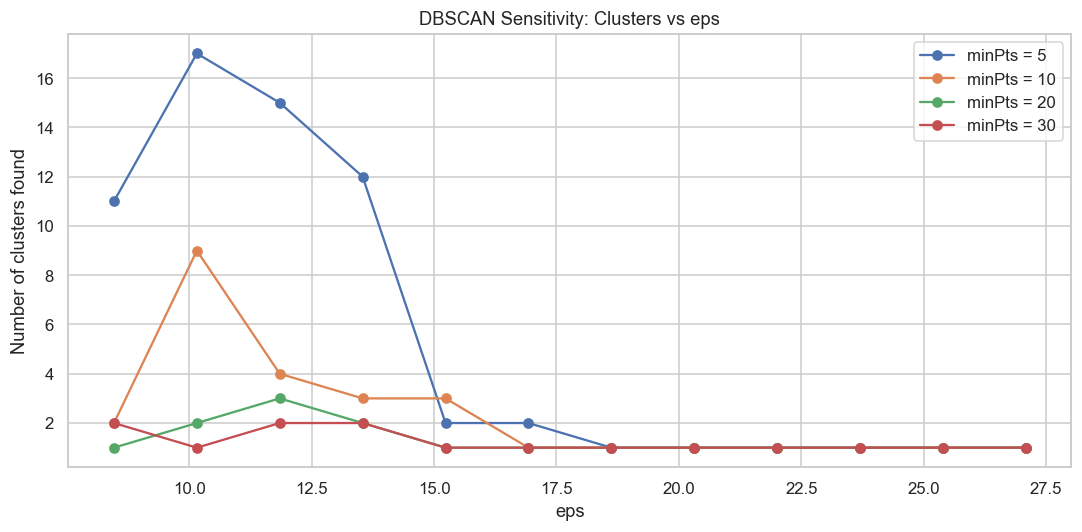

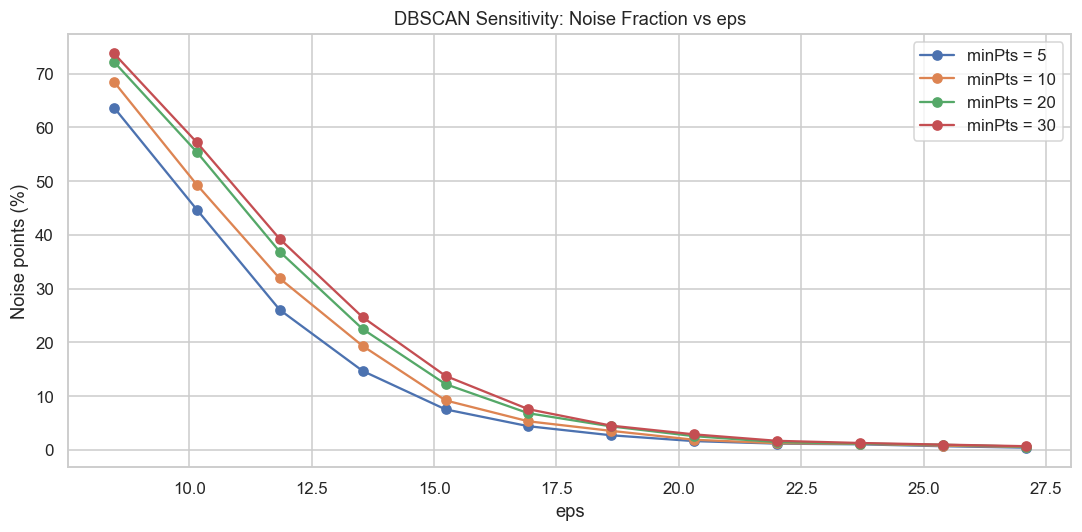

In [69]:
plt.figure(figsize=(10, 5))
for min_pts in min_pts_grid:
    subset = grid_results[grid_results["minPts"] == min_pts]
    plt.plot(subset["eps"], subset["Clusters"], marker="o", label=f"minPts = {min_pts}")
plt.xlabel("eps")
plt.ylabel("Number of clusters found")
plt.title("DBSCAN Sensitivity: Clusters vs eps")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for min_pts in min_pts_grid:
    subset = grid_results[grid_results["minPts"] == min_pts]
    plt.plot(subset["eps"], subset["Noise %"], marker="o", label=f"minPts = {min_pts}")
plt.xlabel("eps")
plt.ylabel("Noise points (%)")
plt.title("DBSCAN Sensitivity: Noise Fraction vs eps")
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
if len(viable) > 0:
    best_row = viable.sort_values("Silhouette", ascending=False).iloc[0]
    BEST_EPS = float(best_row["eps"])
    BEST_MIN_PTS = int(best_row["minPts"])
else:
    BEST_EPS = knee_estimate
    BEST_MIN_PTS = MIN_PTS_REF

print("Selected parameters -> eps =", round(BEST_EPS, 3), ", minPts =", BEST_MIN_PTS)

dbscan = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_PTS, n_jobs=-1)
labels_db = dbscan.fit_predict(X_db)

core_mask = np.zeros(len(labels_db), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
n_core = int(core_mask.sum())
n_noise = int((labels_db == -1).sum())
n_border = len(labels_db) - n_core - n_noise

print("Core points:", n_core)
print("Border points:", n_border)
print("Noise points:", n_noise, f"({round(100 * n_noise / len(labels_db), 2)}%)")
print("Clusters formed:", len(set(labels_db[labels_db != -1])))
print()
print("Cluster sizes:")
print(pd.Series(labels_db).value_counts().sort_index())

Selected parameters -> eps = 13.542 , minPts = 20
Core points: 2572
Border points: 528
Noise points: 900 (22.5%)
Clusters formed: 2

Cluster sizes:
-1     900
 0    2095
 1    1005
Name: count, dtype: int64


In [71]:
result_db = evaluate_clustering(
    f"DBSCAN (eps={round(BEST_EPS, 2)}, minPts={BEST_MIN_PTS})", X_db, labels_db, y_true
)
pd.DataFrame([result_db])

,Algorithm,Clusters,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,"DBSCAN (eps=13.54, minPts=20)",2,22.5,0.4568,0.9415,3086.53,0.3149,0.4695


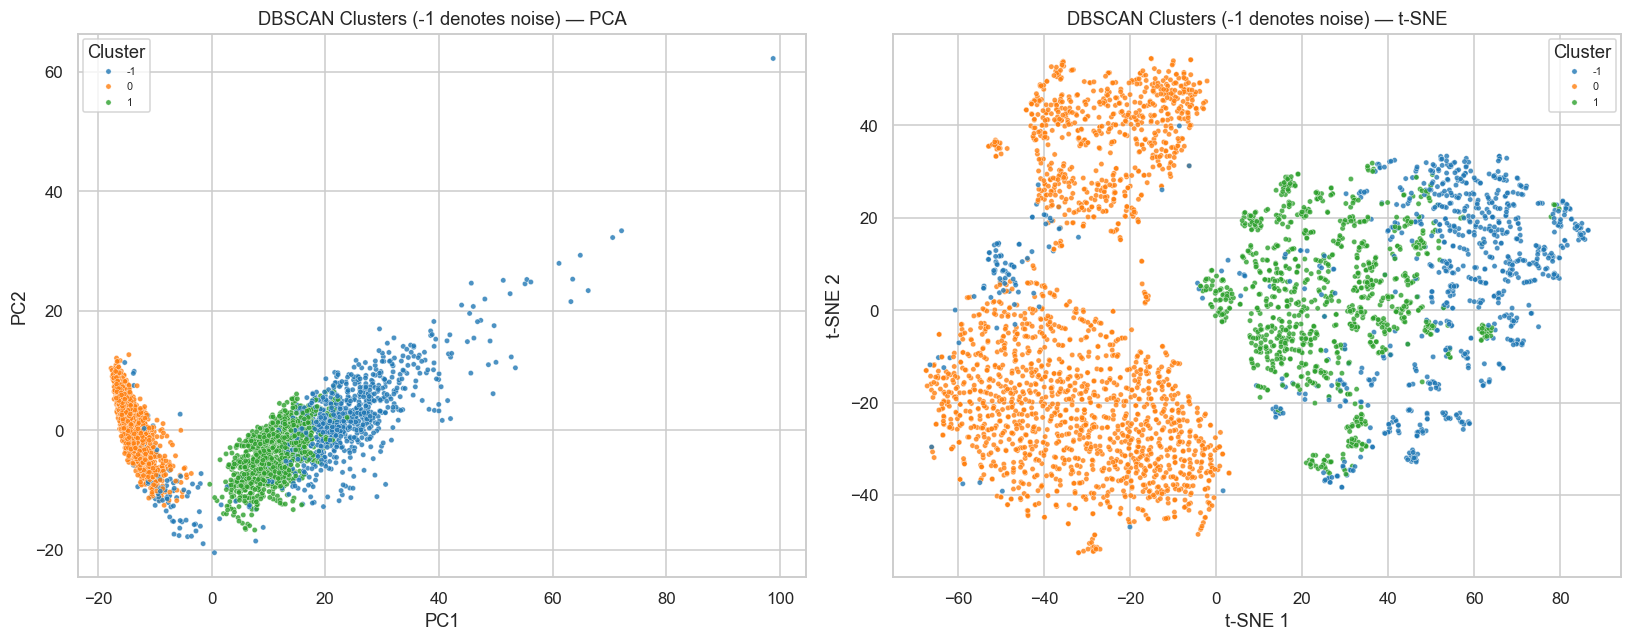

In [72]:
plot_clusters(X_pca2, X_tsne, labels_db, "DBSCAN Clusters (-1 denotes noise)")

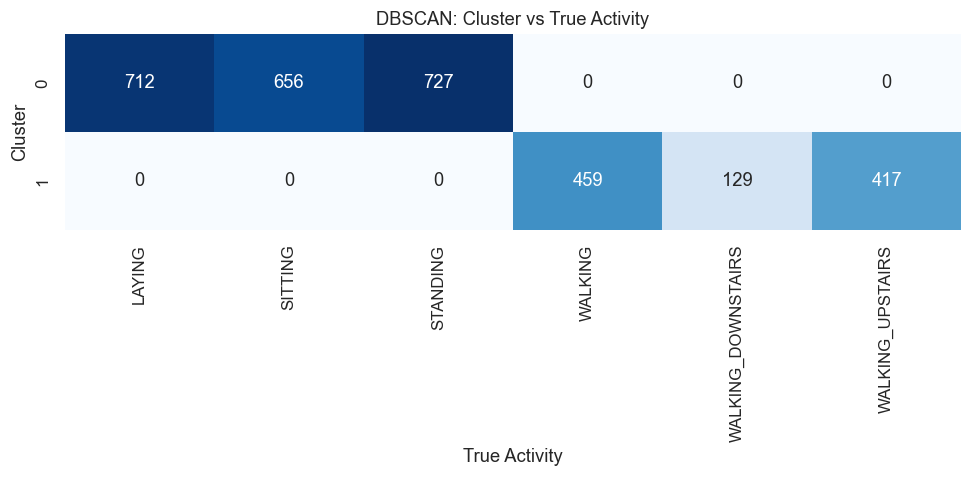

True Activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
Cluster,,,,,,
0,712,656,727,0,0,0
1,0,0,0,459,129,417


In [73]:
db_table = plot_cluster_activity_matrix(
    labels_db, y_true, y_names, "DBSCAN: Cluster vs True Activity"
)
db_table

Percentage of each activity flagged as noise by DBSCAN:
WALKING_DOWNSTAIRS    76.37
WALKING               31.39
WALKING_UPSTAIRS      30.50
LAYING                 5.70
SITTING                4.93
STANDING               1.76


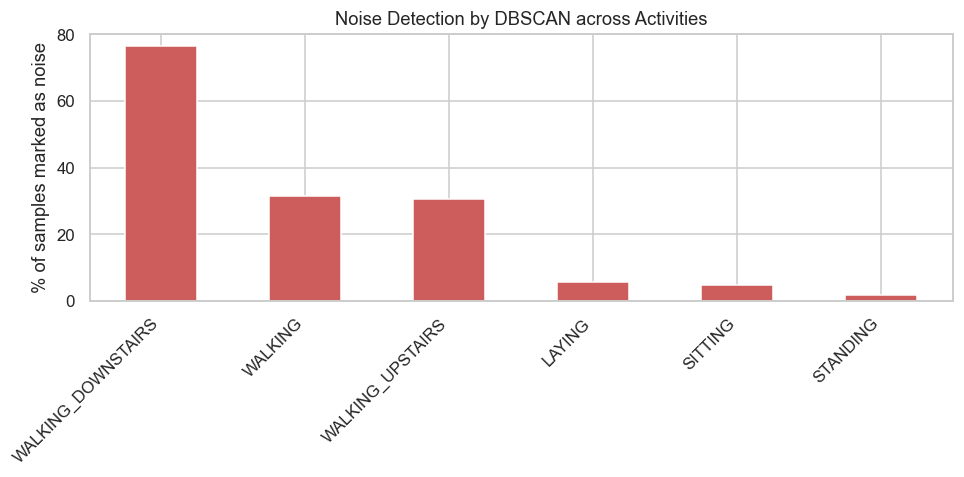

In [74]:
noise_profile = pd.Series(y_names[labels_db == -1]).value_counts()
total_profile = pd.Series(y_names).value_counts()
noise_share = (noise_profile / total_profile * 100).dropna().sort_values(ascending=False)

print("Percentage of each activity flagged as noise by DBSCAN:")
print(noise_share.round(2).to_string())

plt.figure(figsize=(9, 4.5))
noise_share.plot(kind="bar", color="indianred")
plt.ylabel("% of samples marked as noise")
plt.title("Noise Detection by DBSCAN across Activities")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

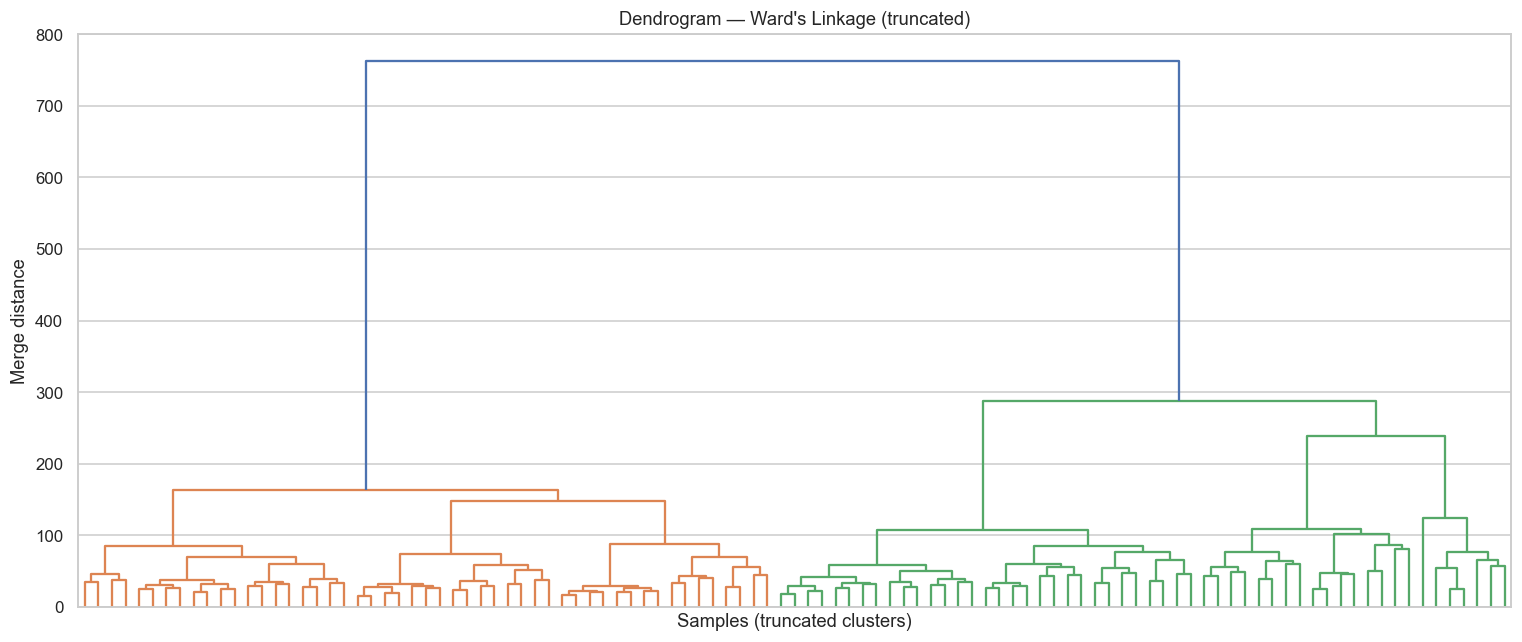

In [75]:
DENDRO_SIZE = min(1200, len(X))
idx = np.random.RandomState(RANDOM_STATE).choice(len(X), DENDRO_SIZE, replace=False)
X_dendro = X[idx]

Z_ward = linkage(X_dendro, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z_ward, truncate_mode="level", p=6, no_labels=True, color_threshold=None)
plt.title("Dendrogram — Ward's Linkage (truncated)")
plt.xlabel("Samples (truncated clusters)")
plt.ylabel("Merge distance")
plt.tight_layout()
plt.show()

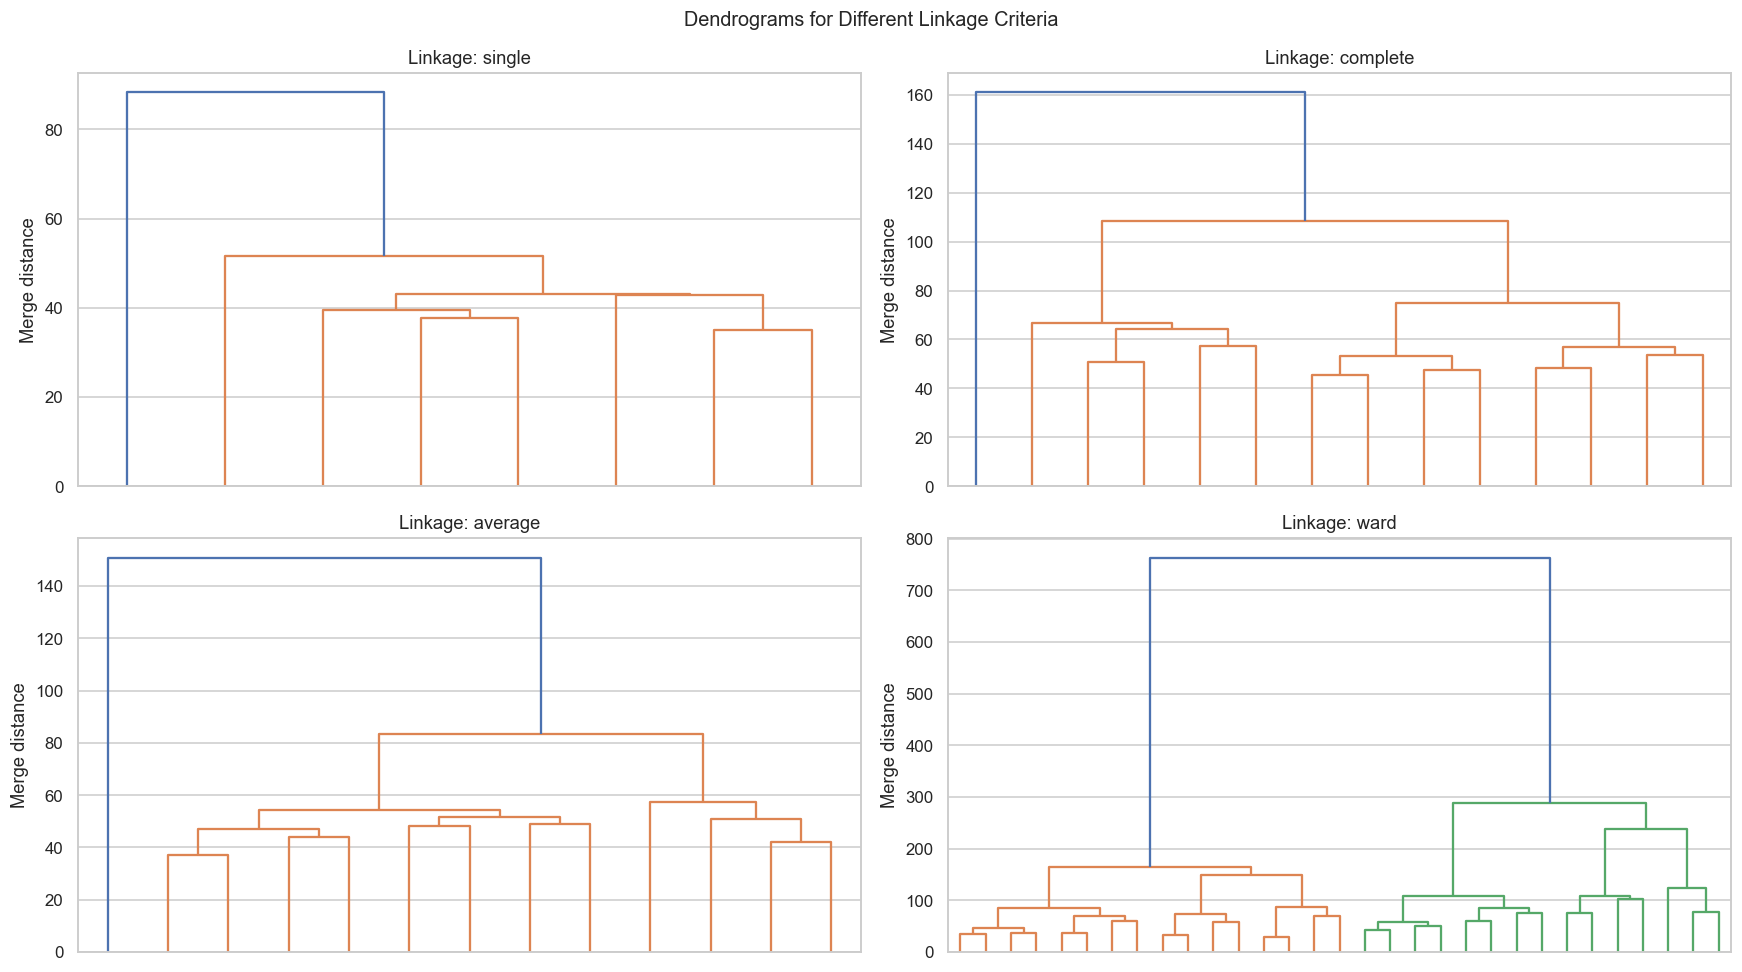

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, method in zip(axes.ravel(), ["single", "complete", "average", "ward"]):
    Z = linkage(X_dendro, method=method)
    dendrogram(Z, truncate_mode="level", p=4, no_labels=True, ax=ax)
    ax.set_title(f"Linkage: {method}")
    ax.set_xlabel("")
    ax.set_ylabel("Merge distance")
fig.suptitle("Dendrograms for Different Linkage Criteria", fontsize=13)
fig.tight_layout()
plt.show()

In [77]:
linkage_records = []
linkage_labels = {}

for method in ["single", "complete", "average", "ward"]:
    metric = "euclidean"
    model = AgglomerativeClustering(n_clusters=FINAL_K, linkage=method, metric=metric)
    labels_h = model.fit_predict(X)
    linkage_labels[method] = labels_h
    row = evaluate_clustering(f"Hierarchical ({method})", X, labels_h, y_true)
    row["Largest cluster %"] = round(
        100 * pd.Series(labels_h).value_counts().max() / len(labels_h), 2
    )
    linkage_records.append(row)

linkage_table = pd.DataFrame(linkage_records)
print(linkage_table.to_string(index=False))
linkage_table

              Algorithm  Clusters  Noise %  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI    NMI  Largest cluster %
  Hierarchical (single)         6      0.0      0.5540          0.2696              17.15 0.0001 0.0026              99.88
Hierarchical (complete)         6      0.0      0.3872          1.1921             717.30 0.3316 0.5524              54.52
 Hierarchical (average)         6      0.0      0.4437          0.8698              35.77 0.0003 0.0088              99.58
    Hierarchical (ward)         6      0.0      0.1262          2.3914             938.72 0.5162 0.6436              33.02


,Algorithm,Clusters,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Largest cluster %
0,Hierarchical (single),6,0.0,0.5540,0.2696,17.15,0.0001,0.0026,99.88
1,Hierarchical (complete),6,0.0,0.3872,1.1921,717.30,0.3316,0.5524,54.52
2,Hierarchical (average),6,0.0,0.4437,0.8698,35.77,0.0003,0.0088,99.58
3,Hierarchical (ward),6,0.0,0.1262,2.3914,938.72,0.5162,0.6436,33.02


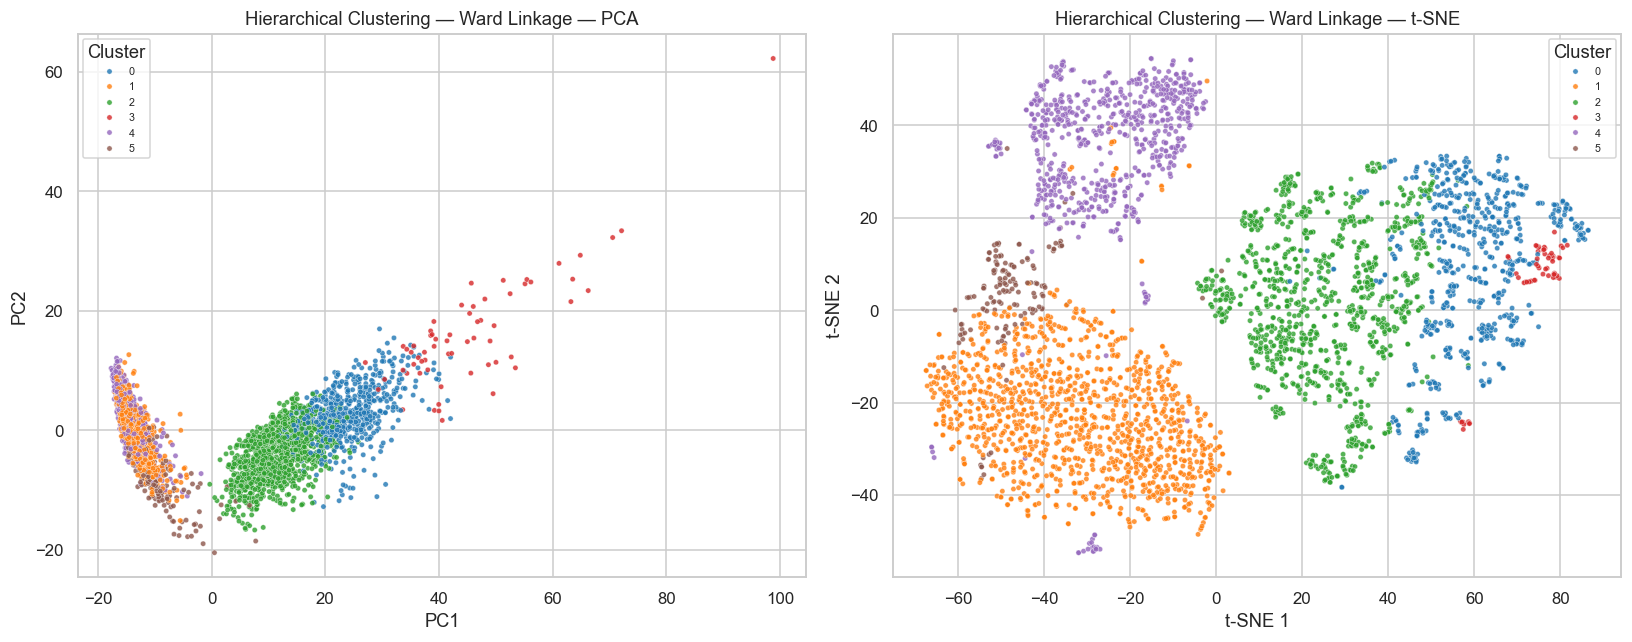

In [78]:
labels_hc = linkage_labels["ward"]
result_hc = evaluate_clustering("Hierarchical (Ward)", X, labels_hc, y_true)

plot_clusters(X_pca2, X_tsne, labels_hc, "Hierarchical Clustering — Ward Linkage")

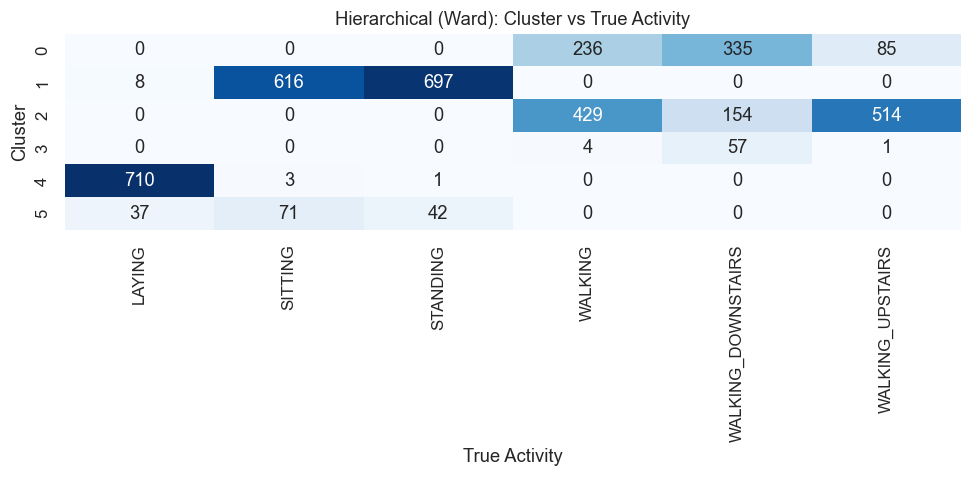

True Activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
Cluster,,,,,,
0,0,0,0,236,335,85
1,8,616,697,0,0,0
2,0,0,0,429,154,514
3,0,0,0,4,57,1
4,710,3,1,0,0,0
5,37,71,42,0,0,0


In [79]:
hc_table = plot_cluster_activity_matrix(
    labels_hc, y_true, y_names, "Hierarchical (Ward): Cluster vs True Activity"
)
hc_table

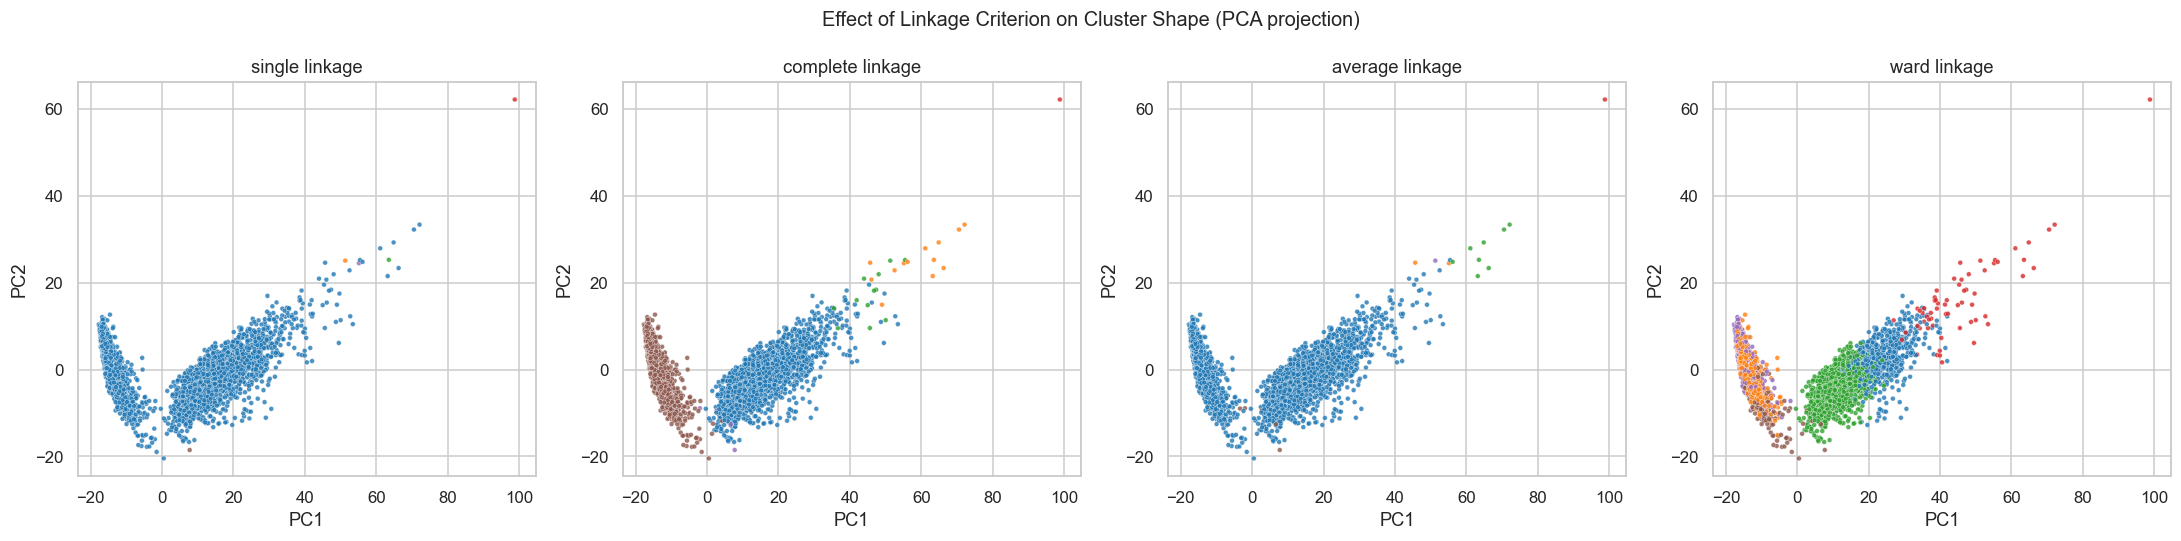

In [80]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, method in zip(axes, ["single", "complete", "average", "ward"]):
    sns.scatterplot(
        x=X_pca2[:, 0], y=X_pca2[:, 1],
        hue=linkage_labels[method], palette="tab10",
        s=10, alpha=0.8, ax=ax, legend=False,
    )
    ax.set_title(f"{method} linkage")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
fig.suptitle("Effect of Linkage Criterion on Cluster Shape (PCA projection)", fontsize=13)
fig.tight_layout()
plt.show()

In [81]:
comparison = pd.DataFrame([
    result_km_best,
    result_km,
    result_db,
    result_hc,
])

print("Comparison of Clustering Algorithms")
print()
print(comparison.to_string(index=False))
comparison

Comparison of Clustering Algorithms

                    Algorithm  Clusters  Noise %  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI    NMI
                K-Means (k=2)         2      0.0      0.3928          1.0720            3048.95 0.3295 0.5456
                K-Means (k=6)         6      0.0      0.1130          2.3635             990.27 0.4227 0.5619
DBSCAN (eps=13.54, minPts=20)         2     22.5      0.4568          0.9415            3086.53 0.3149 0.4695
          Hierarchical (Ward)         6      0.0      0.1262          2.3914             938.72 0.5162 0.6436


,Algorithm,Clusters,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means (k=2),2,0.0,0.3928,1.0720,3048.95,0.3295,0.5456
1,K-Means (k=6),6,0.0,0.1130,2.3635,990.27,0.4227,0.5619
2,"DBSCAN (eps=13.54, minPts=20)",2,22.5,0.4568,0.9415,3086.53,0.3149,0.4695
3,Hierarchical (Ward),6,0.0,0.1262,2.3914,938.72,0.5162,0.6436


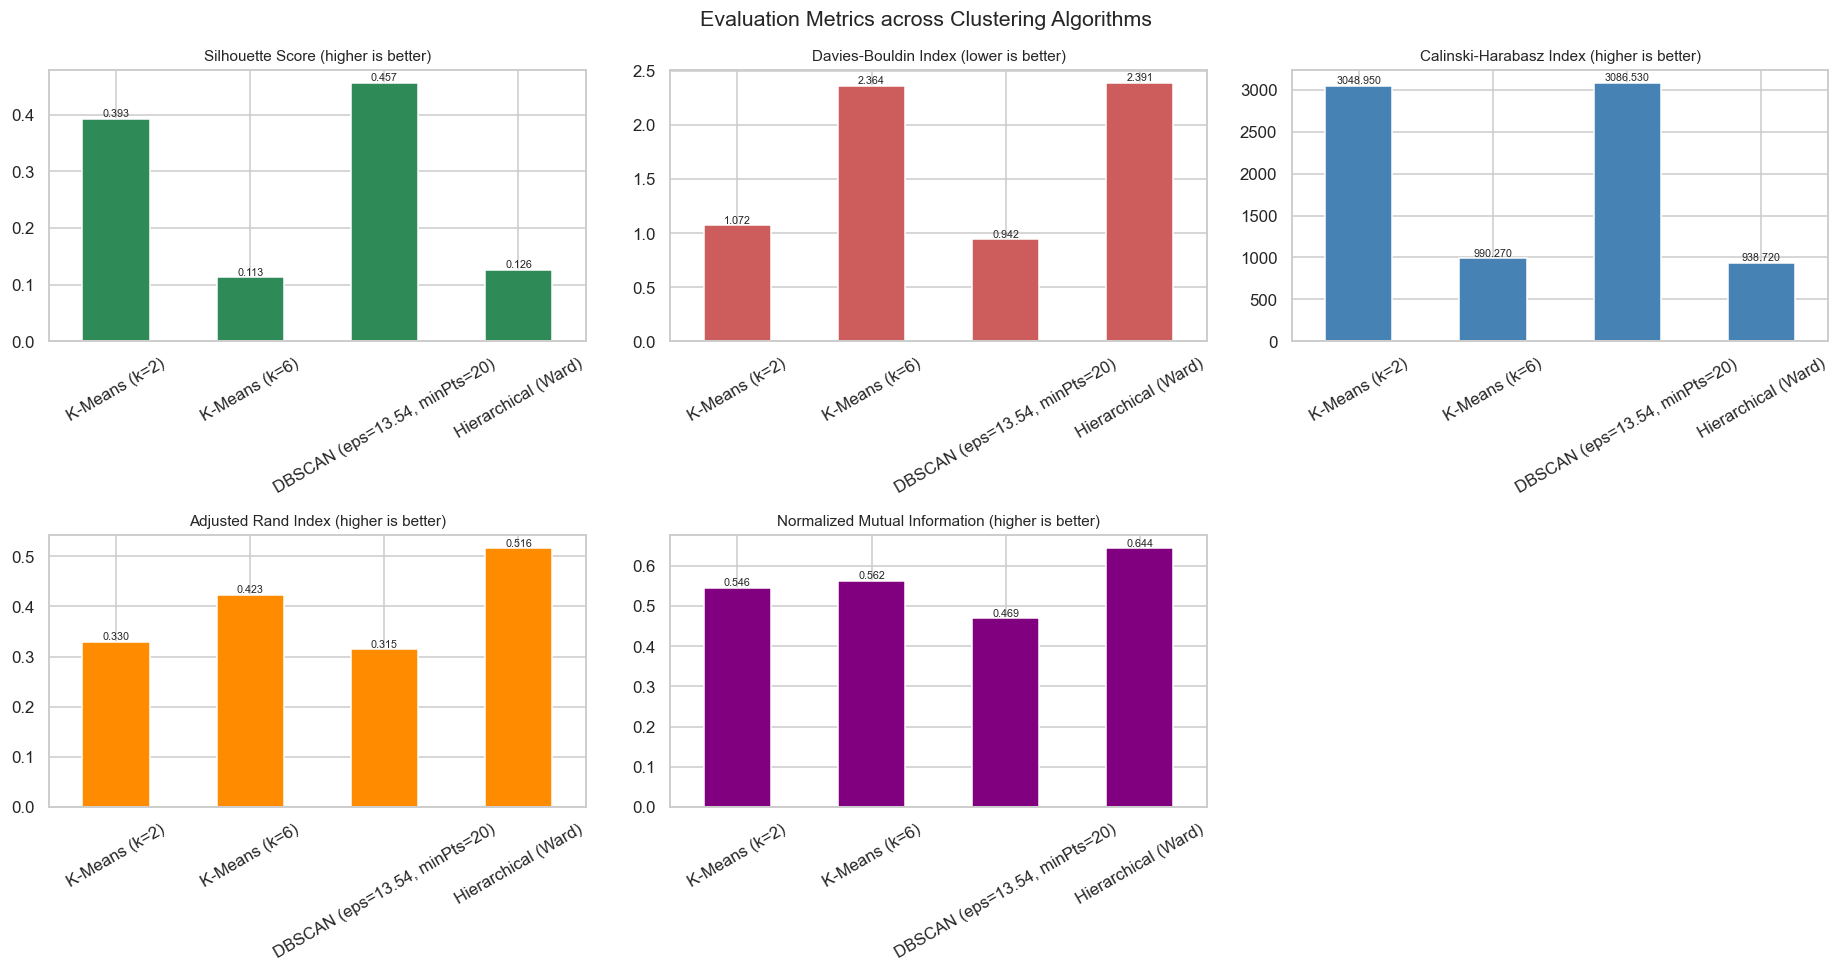

In [82]:
plot_frame = comparison.set_index("Algorithm")
metric_groups = [
    ("Silhouette", "Silhouette Score (higher is better)", "seagreen"),
    ("Davies-Bouldin", "Davies-Bouldin Index (lower is better)", "indianred"),
    ("Calinski-Harabasz", "Calinski-Harabasz Index (higher is better)", "steelblue"),
    ("ARI", "Adjusted Rand Index (higher is better)", "darkorange"),
    ("NMI", "Normalized Mutual Information (higher is better)", "purple"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (metric, title, colour) in zip(axes.ravel(), metric_groups):
    plot_frame[metric].plot(kind="bar", ax=ax, color=colour)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7)

axes.ravel()[-1].axis("off")
fig.suptitle("Evaluation Metrics across Clustering Algorithms", fontsize=14)
fig.tight_layout()
plt.show()

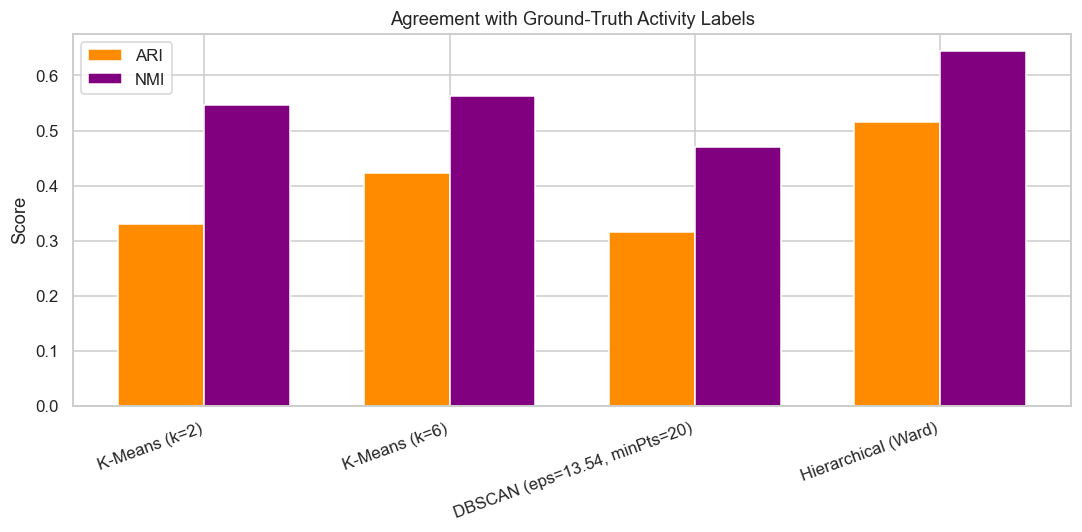

In [83]:
plt.figure(figsize=(10, 5))
width = 0.35
positions = np.arange(len(plot_frame))
plt.bar(positions - width / 2, plot_frame["ARI"], width, label="ARI", color="darkorange")
plt.bar(positions + width / 2, plot_frame["NMI"], width, label="NMI", color="purple")
plt.xticks(positions, plot_frame.index, rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Agreement with Ground-Truth Activity Labels")
plt.legend()
plt.tight_layout()
plt.show()

In [84]:
summary_lines = []
best_internal = comparison.loc[comparison["Silhouette"].idxmax(), "Algorithm"]
best_external = comparison.loc[comparison["ARI"].idxmax(), "Algorithm"]

summary_lines.append(f"Best Silhouette Score: {best_internal}")
summary_lines.append(f"Best agreement with true labels (ARI): {best_external}")
summary_lines.append(f"Optimal k from Silhouette analysis: {BEST_K}")
summary_lines.append(f"Elbow point from WCSS curvature: {elbow_k}")
summary_lines.append(f"DBSCAN parameters used: eps = {round(BEST_EPS, 3)}, minPts = {BEST_MIN_PTS}")
summary_lines.append(f"DBSCAN noise fraction: {result_db['Noise %']}%")
summary_lines.append(f"K-Means cluster-to-activity matching accuracy: {round(accuracy_km * 100, 2)}%")

print("Summary of Results")
print("-" * 55)
for line in summary_lines:
    print(line)

Summary of Results
-------------------------------------------------------
Best Silhouette Score: DBSCAN (eps=13.54, minPts=20)
Best agreement with true labels (ARI): Hierarchical (Ward)
Optimal k from Silhouette analysis: 2
Elbow point from WCSS curvature: 3
DBSCAN parameters used: eps = 13.542, minPts = 20
DBSCAN noise fraction: 22.5%
K-Means cluster-to-activity matching accuracy: 54.17%
